# Spam Email Classification - ML Project

## Dataset Information
- **4,993 observations** of emails classified as Spam or Ham
- **Features**: Label,Message,Label_num
- **Objective**: Classify message as Spam or Ham

<h1>1.Import Libraries</h1>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Sklearn tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ML algorithms (classification)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

<h1>2.Load Raw Data

In [10]:
# Load the dataset
df = pd.read_csv('spam_ham_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
df.head(10)

Dataset loaded successfully!
Shape: (5171, 4)

First few rows:


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
5,2949,ham,Subject: ehronline web address change\r\nthis ...,0
6,2793,ham,Subject: spring savings certificate - take 30 ...,0
7,4185,spam,Subject: looking for medication ? we ` re the ...,1
8,2641,ham,Subject: noms / actual flow for 2 / 26\r\nwe a...,0
9,1870,ham,"Subject: nominations for oct . 21 - 23 , 2000\...",0


## 3. Exploratory Data Analysis (EDA)

<h3>NULL,DUPLICATE & UNIQUE VALUES CHECK

In [11]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Uniques", df.nunique())

Missing values:
 Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
Duplicates: 0
Uniques Unnamed: 0    5171
label            2
text          4993
label_num        2
dtype: int64


<h3>DATA VISUALISATION

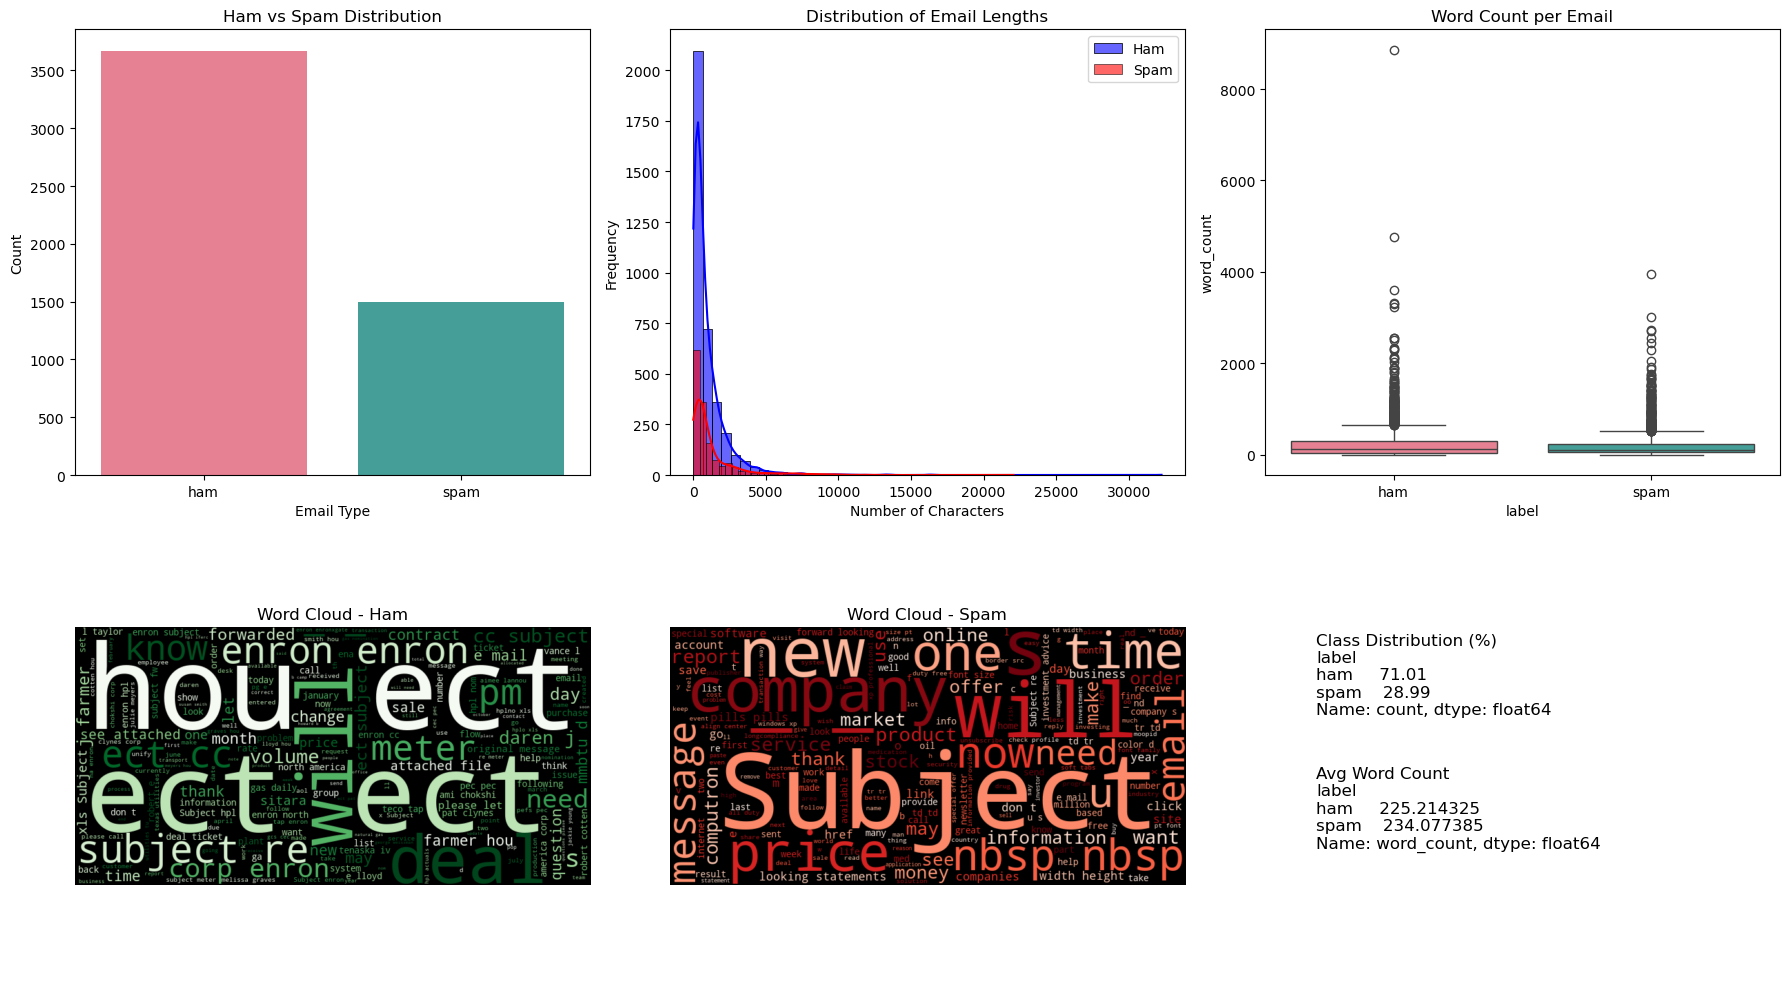

In [12]:
from wordcloud import WordCloud

# Prepare data
class_counts = df['label'].value_counts()
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Create word clouds
ham_wc = WordCloud(width=800, height=400, background_color="black", colormap="Greens") \
            .generate(" ".join(df[df['label']=="ham"]['text']))
spam_wc = WordCloud(width=800, height=400, background_color="black", colormap="Reds") \
            .generate(" ".join(df[df['label']=="spam"]['text']))

# Set up subplot grid (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class distribution
sns.countplot(ax=axes[0,0], x='label', data=df, palette="husl")
axes[0,0].set_title("Ham vs Spam Distribution")
axes[0,0].set_xlabel("Email Type")
axes[0,0].set_ylabel("Count")

# 2. Email length distribution
sns.histplot(df[df['label']=="ham"]['text_length'], bins=50, kde=True, 
             color='blue', label="Ham", alpha=0.6, ax=axes[0,1])
sns.histplot(df[df['label']=="spam"]['text_length'], bins=50, kde=True, 
             color='red', label="Spam", alpha=0.6, ax=axes[0,1])
axes[0,1].legend()
axes[0,1].set_title("Distribution of Email Lengths")
axes[0,1].set_xlabel("Number of Characters")
axes[0,1].set_ylabel("Frequency")

# 3. Word count boxplot
sns.boxplot(ax=axes[0,2], x='label', y='word_count', data=df, palette="husl")
axes[0,2].set_title("Word Count per Email")

# 4. Ham WordCloud
axes[1,0].imshow(ham_wc, interpolation="bilinear")
axes[1,0].axis("off")
axes[1,0].set_title("Word Cloud - Ham")

# 5. Spam WordCloud
axes[1,1].imshow(spam_wc, interpolation="bilinear")
axes[1,1].axis("off")
axes[1,1].set_title("Word Cloud - Spam")

# 6. Empty slot → we can use for summary text or stats
axes[1,2].axis("off")
axes[1,2].text(0.1, 0.6, "Class Distribution (%)\n" + str(round(class_counts/len(df)*100,2)),
               fontsize=12, wrap=True)
axes[1,2].text(0.1, 0.3, "Avg Word Count\n" + str(df.groupby('label')['word_count'].mean()),
               fontsize=12, wrap=True)

plt.tight_layout()
plt.show()

<h1>FEATURE ENGINEERING

In [13]:
df.drop(columns=['Unnamed: 0', 'label'], inplace=True)
df.head(10)

,text,label_num,text_length,word_count
0,Subject: enron methanol ; meter # : 988291\r\n...,0,327,67
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,23
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,550
3,"Subject: photoshop , windows , office . cheap ...",1,414,48
4,Subject: re : indian springs\r\nthis deal is t...,0,336,70
5,Subject: ehronline web address change\r\nthis ...,0,480,98
6,Subject: spring savings certificate - take 30 ...,0,2076,385
7,Subject: looking for medication ? we ` re the ...,1,784,164
8,Subject: noms / actual flow for 2 / 26\r\nwe a...,0,582,170
9,"Subject: nominations for oct . 21 - 23 , 2000\...",0,105,25


In [14]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                             # lowercase
    text = re.sub(r"[^a-z\s]", "", text)            # keep only letters
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]   # lemmatization
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<h1>TRAIN TEST SPLIT

In [15]:
X_text = df['clean_text']
y = df['label_num']

# Split first!
X_train_text, X_test_text, y_train, y_test, train_idx, test_idx = train_test_split(
    X_text, y, df.index, test_size=0.2, stratify=y, random_state=42
)

# Extract numeric features separately
X_train_num = df.loc[train_idx, ['char_count', 'word_count']].values
X_test_num = df.loc[test_idx, ['char_count', 'word_count']].values

<h1>VECTORIZATION

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


<h1>STANDARDISATION

In [17]:
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Combine TF-IDF + numeric features
X_train_final = hstack([X_train_tfidf, X_train_num_scaled])
X_test_final = hstack([X_test_tfidf, X_test_num_scaled])

<h1>ML ALGORITHMS

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define baseline models
baseline_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1] if hasattr(model, "predict_proba") else None
    
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    })

baseline_df = pd.DataFrame(baseline_results).sort_values(by="F1-Score", ascending=False)
baseline_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC
6,XGBoost,0.982609,0.960784,0.980000,0.970297,0.997211
2,RandomForest,0.981643,0.954693,0.983333,0.968801,0.998023
3,SVM,0.978744,0.942675,0.986667,0.964169,0.998526
5,AdaBoost,0.971014,0.941176,0.960000,0.950495,0.992286
0,LogisticRegression,0.965217,0.900000,0.990000,0.942857,0.995175
4,KNN,0.959420,0.935811,0.923333,0.929530,0.985934
1,DecisionTree,0.942029,0.908163,0.890000,0.898990,0.926633


<h1>HYPERPARAMETER TUNING

In [20]:
# Dictionary of models with hyperparameter grids
param_grids = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(class_weight='balanced', random_state=42),
        "params": {
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "SVM": {
        "model": SVC(probability=True, class_weight='balanced', random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["minkowski", "euclidean"]
        }
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200, 300],
            "learning_rate": [0.01, 0.1, 1]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.7, 0.8, 1.0]
        }
    }
}

# Run GridSearchCV for all models
best_models = {}
for name, mp in param_grids.items():
    print(f"Tuning hyperparameters for {name}...")
    grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_final, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best parameters for {name}: {grid.best_params_}\n")


Tuning hyperparameters for LogisticRegression...
Best parameters for LogisticRegression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Tuning hyperparameters for DecisionTree...
Best parameters for DecisionTree: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuning hyperparameters for RandomForest...
Best parameters for RandomForest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Tuning hyperparameters for SVM...
Best parameters for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Tuning hyperparameters for KNN...
Best parameters for KNN: {'metric': 'minkowski', 'n_neighbors': 5, 'weights': 'distance'}

Tuning hyperparameters for AdaBoost...
Best parameters for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 300}

Tuning hyperparameters for XGBoost...
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}



In [21]:
tuned_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1] if hasattr(model, "predict_proba") else None
    
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Confusion_Matrix": confusion_matrix(y_test, y_pred)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1-Score", ascending=False)
tuned_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC,Confusion_Matrix
2,RandomForest,0.981643,0.948882,0.990000,0.969005,0.997977,"[[719, 16], [3, 297]]"
0,LogisticRegression,0.981643,0.951768,0.986667,0.968903,0.998385,"[[720, 15], [4, 296]]"
6,XGBoost,0.978744,0.945513,0.983333,0.964052,0.997077,"[[718, 17], [5, 295]]"
3,SVM,0.978744,0.948387,0.980000,0.963934,0.998444,"[[719, 16], [6, 294]]"
5,AdaBoost,0.965217,0.915094,0.970000,0.941748,0.994853,"[[708, 27], [9, 291]]"
4,KNN,0.963285,0.939597,0.933333,0.936455,0.987238,"[[717, 18], [20, 280]]"
1,DecisionTree,0.941063,0.874608,0.930000,0.901454,0.935265,"[[695, 40], [21, 279]]"


<h1>BAGGING AND BOOSTING

In [22]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

bagging_models = {
    "Bagging_DT": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, random_state=42
    ),
    "Bagging_KNN": BaggingClassifier(
        estimator=KNeighborsClassifier(),
        n_estimators=100, random_state=42
    )
}

bagging_results = []

for name, model in bagging_models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1] if hasattr(model, "predict_proba") else None
    
    bagging_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Confusion_Matrix": confusion_matrix(y_test, y_pred)
    })

bagging_df = pd.DataFrame(bagging_results).sort_values(by="F1-Score", ascending=False)
bagging_df
boosting_models = {
    "AdaBoost_DT": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=300, learning_rate=0.1, random_state=42
    ),
    "AdaBoost_LR": AdaBoostClassifier(
        estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, use_label_encoder=False, eval_metric='logloss', random_state=42
    )
}

boosting_results = []

for name, model in boosting_models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:,1] if hasattr(model, "predict_proba") else None
    
    boosting_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Confusion_Matrix": confusion_matrix(y_test, y_pred)
    })

boosting_df = pd.DataFrame(boosting_results).sort_values(by="F1-Score", ascending=False)
boosting_df
# Combine results
ensemble_df = pd.concat([bagging_df, boosting_df], ignore_index=True)
ensemble_df = ensemble_df.sort_values(by="F1-Score", ascending=False)
ensemble_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Confusion_Matrix
2,XGBoost,0.977778,0.951140,0.973333,0.962109,0.997102,"[[720, 15], [8, 292]]"
3,AdaBoost_DT,0.965217,0.915094,0.970000,0.941748,0.994853,"[[708, 27], [9, 291]]"
0,Bagging_KNN,0.964251,0.942761,0.933333,0.938023,0.993023,"[[718, 17], [20, 280]]"
1,Bagging_DT,0.957488,0.902516,0.956667,0.928803,0.995111,"[[704, 31], [13, 287]]"
4,AdaBoost_LR,0.902415,0.766756,0.953333,0.849926,0.947918,"[[648, 87], [14, 286]]"


<h1>COMPARATIVE ANALYSIS

In [23]:
def evaluate_models(models_dict, X_test, y_test):
    results = []
    
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
        
        results.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1-Score": round(f1_score(y_test, y_pred), 4),
            "AUC": round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None,
            "Confusion_Matrix": confusion_matrix(y_test, y_pred)
        })
    return pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
baseline_df = evaluate_models(baseline_models, X_test_final, y_test)
baseline_df["Type"] = "Baseline"
tuned_df = evaluate_models(best_models, X_test_final, y_test)
tuned_df["Type"] = "Hyperparameter Tuned"
bagging_df["Type"] = "Bagging"
boosting_df["Type"] = "Boosting"
comparative_df = pd.concat([baseline_df, tuned_df, bagging_df, boosting_df], ignore_index=True)
comparative_df = comparative_df.sort_values(by="F1-Score", ascending=False)
comparative_df.reset_index(drop=True, inplace=True)
comparative_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Confusion_Matrix,Type
0,XGBoost,0.982600,0.960800,0.980000,0.970300,0.997200,"[[723, 12], [6, 294]]",Baseline
1,RandomForest,0.981600,0.948900,0.990000,0.969000,0.998000,"[[719, 16], [3, 297]]",Hyperparameter Tuned
2,LogisticRegression,0.981600,0.951800,0.986700,0.968900,0.998400,"[[720, 15], [4, 296]]",Hyperparameter Tuned
3,RandomForest,0.981600,0.954700,0.983300,0.968800,0.998000,"[[721, 14], [5, 295]]",Baseline
4,SVM,0.978700,0.942700,0.986700,0.964200,0.998500,"[[717, 18], [4, 296]]",Baseline
5,XGBoost,0.978700,0.945500,0.983300,0.964100,0.997100,"[[718, 17], [5, 295]]",Hyperparameter Tuned
6,SVM,0.978700,0.948400,0.980000,0.963900,0.998400,"[[719, 16], [6, 294]]",Hyperparameter Tuned
7,XGBoost,0.977778,0.951140,0.973333,0.962109,0.997102,"[[720, 15], [8, 292]]",Boosting
8,AdaBoost,0.971000,0.941200,0.960000,0.950500,0.992300,"[[717, 18], [12, 288]]",Baseline
9,LogisticRegression,0.965200,0.900000,0.990000,0.942900,0.995200,"[[702, 33], [3, 297]]",Baseline


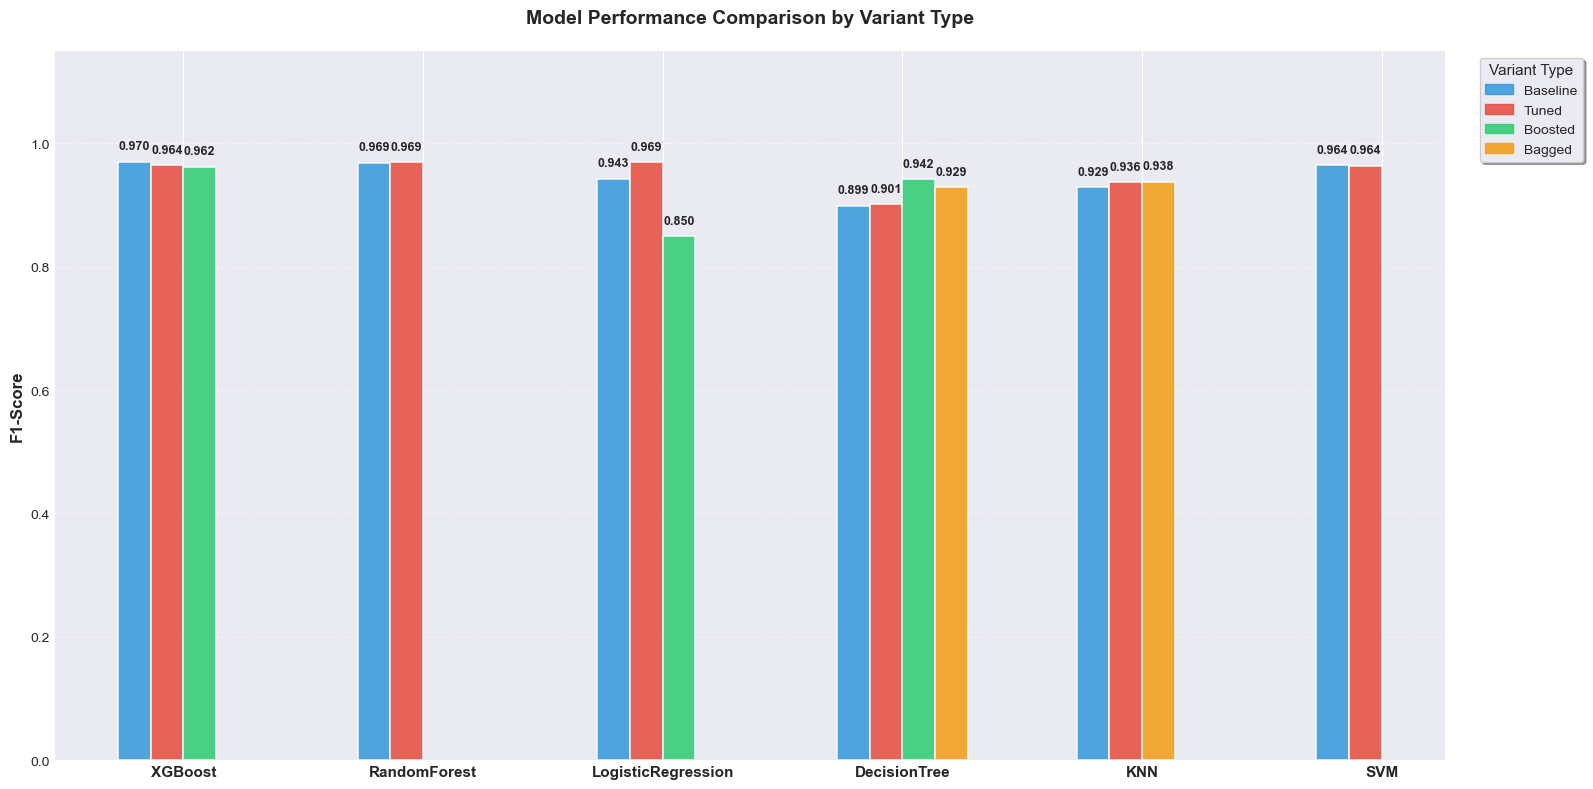


PERFORMANCE SUMMARY
Variant_Type        Bagged  Baseline  Boosted   Tuned
Base_Algo                                            
DecisionTree        0.9288    0.8990   0.9417  0.9015
KNN                 0.9380    0.9295      NaN  0.9365
LogisticRegression     NaN    0.9429   0.8499  0.9689
Other                  NaN    0.9505      NaN  0.9417
RandomForest           NaN    0.9688      NaN  0.9690
SVM                    NaN    0.9642      NaN  0.9639
XGBoost                NaN    0.9703   0.9621  0.9641

BEST VARIANT PER ALGORITHM
             Base_Algo               Model Variant_Type  F1-Score
0              XGBoost             XGBoost     Baseline  0.970300
1         RandomForest        RandomForest        Tuned  0.969000
2   LogisticRegression  LogisticRegression        Tuned  0.968900
4                  SVM                 SVM     Baseline  0.964200
8                Other            AdaBoost     Baseline  0.950500
10        DecisionTree         AdaBoost_DT      Boosted  0.941748
12 

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1️⃣ Simplified mapping functions
def map_base_algo(model_name):
    algo_map = {
        'XGBoost': 'XGBoost', 'Random': 'RandomForest', 
        'Logistic': 'LogisticRegression', 'AdaBoost_LR': 'LogisticRegression',
        'Decision': 'DecisionTree', 'AdaBoost_DT': 'DecisionTree', 'Bagging_DT': 'DecisionTree',
        'KNN': 'KNN', 'Bagging_KNN': 'KNN', 'SVM': 'SVM'
    }
    return next((v for k, v in algo_map.items() if k in model_name), 'Other')

def map_variant_type(row):
    model, type_val = row['Model'].lower(), str(row.get('Type', '')).lower()
    
    # Check Type column first
    if 'baseline' in type_val: return 'Baseline'
    if 'tuned' in type_val: return 'Tuned'
    if 'bag' in type_val or 'bagging' in model: return 'Bagged'
    if 'boost' in type_val or 'adaboost' in model: return 'Boosted'
    
    # Fallback to model name inference
    return 'Tuned' if 'tuned' in model else 'Baseline'

# 2️⃣ Apply mappings
comparative_df['Base_Algo'] = comparative_df['Model'].apply(map_base_algo)
comparative_df['Variant_Type'] = comparative_df.apply(map_variant_type, axis=1)

# 3️⃣ Enhanced visualization
color_map = {'Baseline': '#3498db', 'Tuned': '#e74c3c', 'Boosted': '#2ecc71', 'Bagged': '#f39c12'}
algo_order = ['XGBoost', 'RandomForest', 'LogisticRegression', 'DecisionTree', 'KNN', 'SVM']
groups = [algo for algo in algo_order if algo in comparative_df['Base_Algo'].unique()]

# Set up plot with better styling
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(16, 8))

# Calculate positions
max_variants = comparative_df.groupby('Base_Algo').size().max()
bar_width, group_spacing = 0.18, 0.6
group_positions = np.arange(len(groups)) * (max_variants * bar_width + group_spacing)

# Plot bars with improved styling
sort_order = {'Baseline': 0, 'Tuned': 1, 'Boosted': 2, 'Bagged': 3}
for i, group in enumerate(groups):
    group_df = comparative_df[comparative_df['Base_Algo'] == group].sort_values(
        by='Variant_Type', key=lambda x: x.map(sort_order)
    )
    
    for j, (_, row) in enumerate(group_df.iterrows()):
        color = color_map.get(row['Variant_Type'], color_map['Baseline'])
        bar = ax.bar(group_positions[i] + j*bar_width, row['F1-Score'], 
                     width=bar_width, color=color, edgecolor='white', linewidth=1.2, alpha=0.85)
        
        # Add value labels with better positioning
        ax.text(group_positions[i] + j*bar_width, row['F1-Score'] + 0.015, 
                f'{row["F1-Score"]:.3f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold', rotation=0)

# Styling improvements
ax.set_xticks(group_positions + (bar_width * 1.5))
ax.set_xticklabels(groups, fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison by Variant Type', 
             fontsize=14, fontweight='bold', pad=20)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Enhanced legend
handles = [plt.Rectangle((0,0),1,1, color=color_map[k], alpha=0.85) 
           for k in ['Baseline', 'Tuned', 'Boosted', 'Bagged']]
ax.legend(handles, ['Baseline', 'Tuned', 'Boosted', 'Bagged'], 
          title='Variant Type', title_fontsize=11, fontsize=10,
          bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.8)
plt.tight_layout()
plt.show()

# 4️⃣ Compact summary output
print('\n' + '='*60)
print('PERFORMANCE SUMMARY')
print('='*60)
summary = comparative_df.pivot_table(
    values='F1-Score', index='Base_Algo', columns='Variant_Type', aggfunc='mean'
).round(4)
print(summary)

print('\n' + '='*60)
print('BEST VARIANT PER ALGORITHM')
print('='*60)
best_variants = comparative_df.loc[comparative_df.groupby('Base_Algo')['F1-Score'].idxmax()]
print(best_variants[['Base_Algo', 'Model', 'Variant_Type', 'F1-Score']].sort_values('F1-Score', ascending=False))


<h1>ENSEMBLE MODEL

In [102]:
# Ensemble Model using VotingClassifier (Stacking of best tuned models)
from sklearn.ensemble import VotingClassifier

# Prepare the best models for ensemble (from hyperparameter tuning)
ensemble_estimators = [
    ('lr', best_models['LogisticRegression']),
    ('dt', best_models['DecisionTree']),
    ('rf', best_models['RandomForest']),
    ('svm', best_models['SVM']),
    ('knn', best_models['KNN']),
    ('ada', best_models['AdaBoost']),
    ('xgb', best_models['XGBoost'])
]

# Create a soft voting ensemble (uses predicted probabilities)
ensemble_clf = VotingClassifier(estimators=ensemble_estimators, voting='soft', n_jobs=-1)
ensemble_clf.fit(X_train_final, y_train)

# Evaluate ensemble model
y_pred_ensemble = ensemble_clf.predict(X_test_final)
y_prob_ensemble = ensemble_clf.predict_proba(X_test_final)[:,1]

ensemble_metrics = {
    'Model': 'VotingEnsemble',
    'Accuracy': accuracy_score(y_test, y_pred_ensemble),
    'Precision': precision_score(y_test, y_pred_ensemble),
    'Recall': recall_score(y_test, y_pred_ensemble),
    'F1-Score': f1_score(y_test, y_pred_ensemble),
    'AUC': roc_auc_score(y_test, y_prob_ensemble),
    'Confusion_Matrix': confusion_matrix(y_test, y_pred_ensemble)
}

print('Ensemble Model Performance:')
for k, v in ensemble_metrics.items():
    print(f'{k}: {v}')

# Optionally, add to comparative_df for visualization
ensemble_row = pd.DataFrame([ensemble_metrics])
ensemble_row['Type'] = 'VotingEnsemble'
comparative_df = pd.concat([comparative_df, ensemble_row], ignore_index=True)
comparative_df = comparative_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
comparative_df

Ensemble Model Performance:
Model: VotingEnsemble
Accuracy: 0.9845410628019323
Precision: 0.9580645161290322
Recall: 0.99
F1-Score: 0.9737704918032787
AUC: 0.9990612244897958
Confusion_Matrix: [[722  13]
 [  3 297]]


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Confusion_Matrix,Type
0,VotingEnsemble,0.984541,0.958065,0.990000,0.973770,0.999061,"[[722, 13], [3, 297]]",VotingEnsemble
1,XGBoost,0.982600,0.960800,0.980000,0.970300,0.997200,"[[723, 12], [6, 294]]",Baseline
2,RandomForest,0.981600,0.948900,0.990000,0.969000,0.998000,"[[719, 16], [3, 297]]",Hyperparameter Tuned
3,LogisticRegression,0.981600,0.951800,0.986700,0.968900,0.998400,"[[720, 15], [4, 296]]",Hyperparameter Tuned
4,RandomForest,0.981600,0.954700,0.983300,0.968800,0.998000,"[[721, 14], [5, 295]]",Baseline
5,SVM,0.978700,0.942700,0.986700,0.964200,0.998500,"[[717, 18], [4, 296]]",Baseline
6,XGBoost,0.978700,0.945500,0.983300,0.964100,0.997100,"[[718, 17], [5, 295]]",Hyperparameter Tuned
7,SVM,0.978700,0.948400,0.980000,0.963900,0.998400,"[[719, 16], [6, 294]]",Hyperparameter Tuned
8,XGBoost,0.977778,0.951140,0.973333,0.962109,0.997102,"[[720, 15], [8, 292]]",Boosting
9,AdaBoost,0.971000,0.941200,0.960000,0.950500,0.992300,"[[717, 18], [12, 288]]",Baseline


<h1>SUMMARY

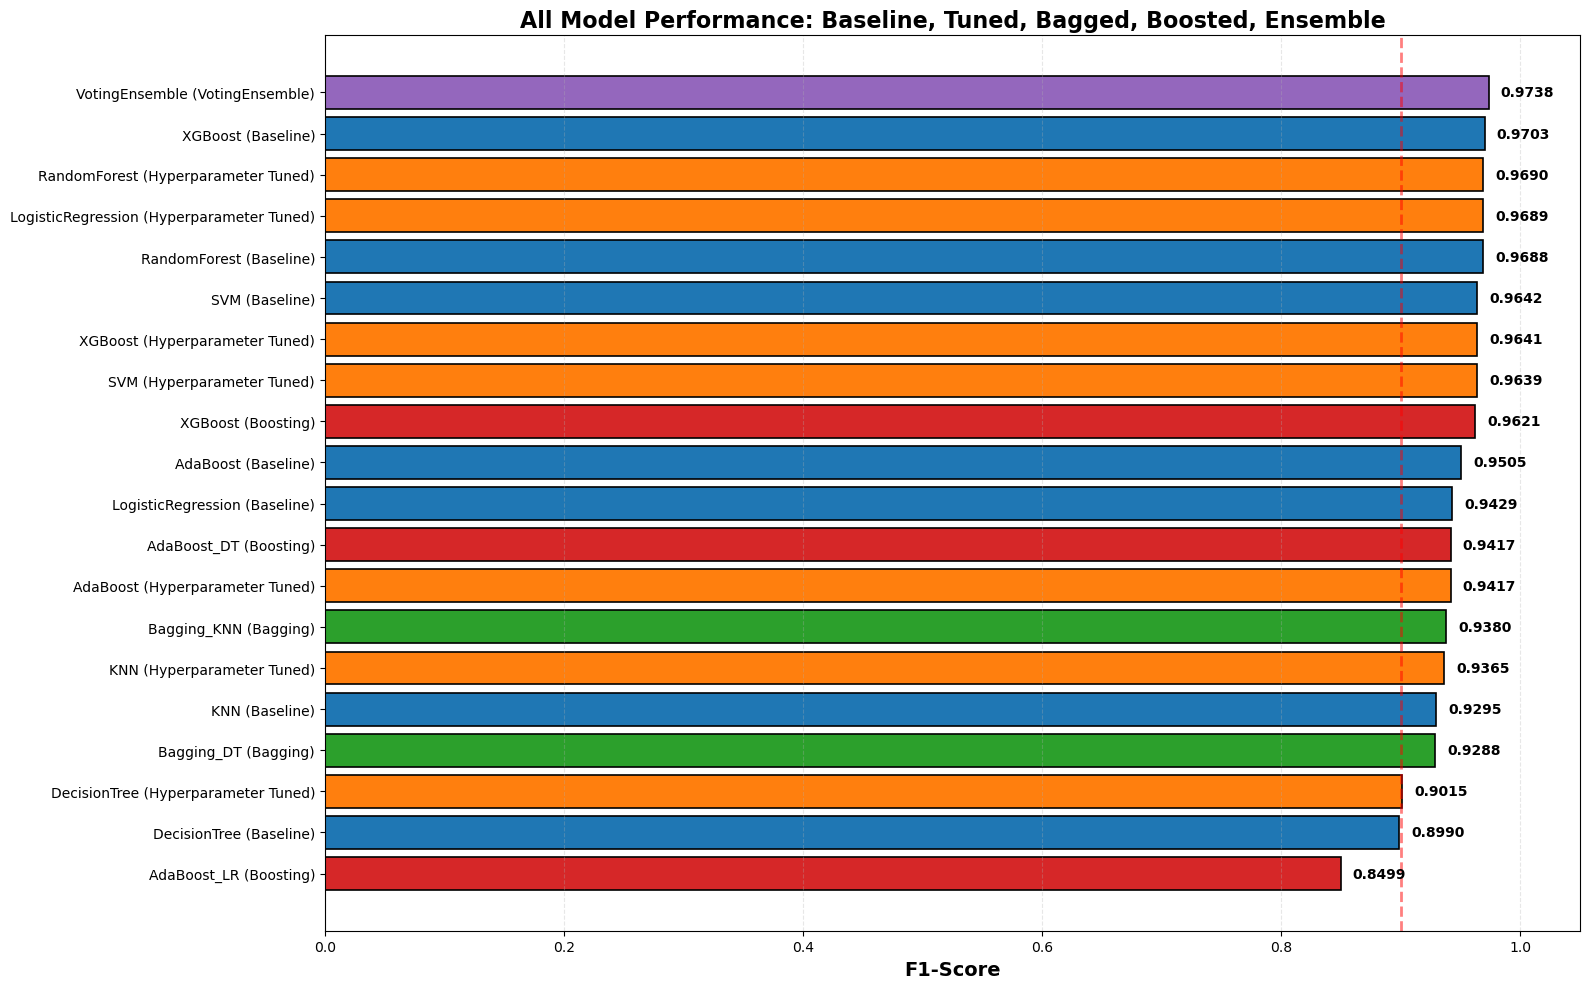

In [103]:
# Final visualization - All models (Baseline, Tuned, Bagged, Boosted, Ensemble)
fig, ax = plt.subplots(1, 1, figsize=(16, max(8, int(0.5*len(comparative_df)))))

# Sort by F1-Score for better visualization
plot_data = comparative_df.copy().sort_values('F1-Score')

# Create color palette for model types
type_palette = {
    'Baseline': '#1f77b4',
    'Hyperparameter Tuned': '#ff7f0e',
    'Bagging': '#2ca02c',
    'Boosting': '#d62728',
    'VotingEnsemble': '#9467bd'
}
colors = plot_data['Type'].map(type_palette).fillna('#8c564b')

# Horizontal bars for all models
bars = ax.barh(plot_data['Model'] + ' (' + plot_data['Type'] + ')', plot_data['F1-Score'], color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, f1_val in zip(bars, plot_data['F1-Score']):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{f1_val:.4f}',
            ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('F1-Score', fontsize=14, fontweight='bold')
ax.set_title('All Model Performance: Baseline, Tuned, Bagged, Boosted, Ensemble', fontsize=16, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=0.90, color='red', linestyle='--', linewidth=2, alpha=0.5, label='90% threshold')

plt.tight_layout()
plt.show()